In [15]:
## DOWNLOADING DATA
import os
import tarfile
from six.moves import urllib
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    
fetch_housing_data()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_housing_csv(data_path=HOUSING_PATH):
    csv_path = os.path.join(data_path, "housing.csv")
    return pd.read_csv(csv_path)

df = load_housing_csv()
df.head(5)
#df.info

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
#shows amount of repeatable columns 
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [18]:
# count -> how many non-empty values are in each column
# Example: longitude has 20640 values, but total_bedrooms has 20433,
# so some values are missing in total_bedrooms.

# mean -> the average value in that column
# Example: mean longitude = -119.57, mean median_income = 3.87.

# std -> standard deviation, which shows how spread out the values are
# A bigger std means the values vary more.
# Example: total_rooms has std = 2181.62, so room counts differ a lot.

# min -> the smallest value in the column
# Example: minimum housing_median_age = 1, minimum population = 3.

# 25% -> first quartile (Q1)
# 25% of values are less than or equal to this number.
# Example: 25% of districts have median_income <= 2.56.

# 50% -> median (middle value)
# Half of the values are below this number and half are above it.
# Example: median_house_value = 179700.

# 75% -> third quartile (Q3)
# 75% of values are less than or equal to this number.
# Example: 75% of districts have total_rooms <= 3148.

# max -> the largest value in the column
# Example: maximum median_house_value = 500001.
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


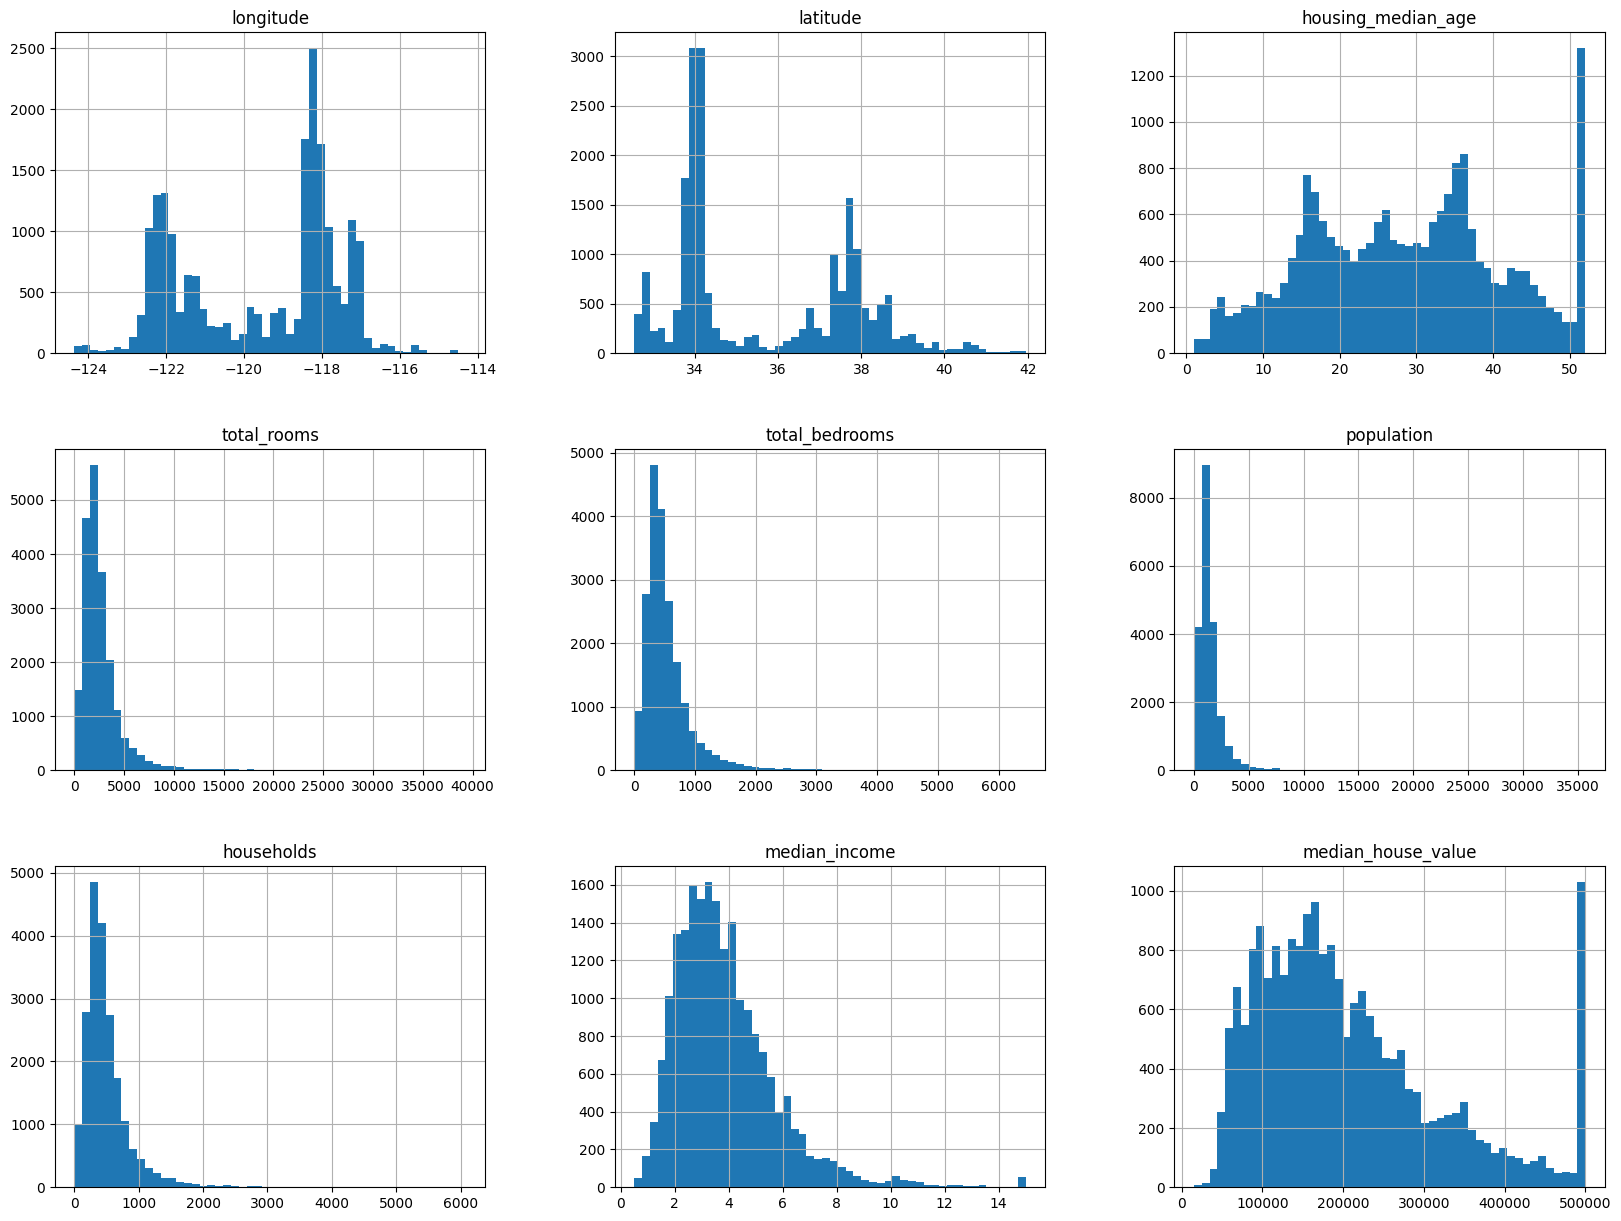

In [19]:
df.hist(bins=50, figsize=(20,15))
plt.show()

<Axes: >

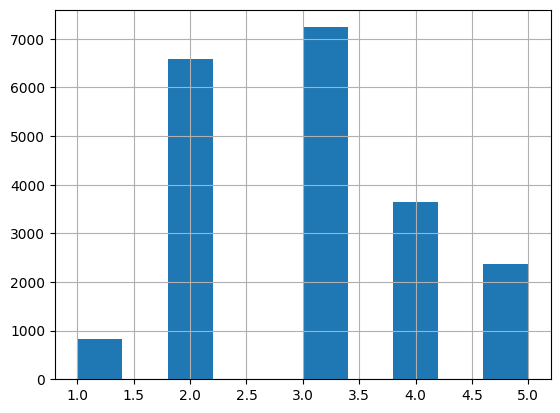

In [20]:
# Create a new column called "income_cat"
# We take the "median_income" column and divide each value by 1.5
# Then np.ceil(...) rounds each result UP to the nearest whole number
df["income_category"] = np.ceil(df["median_income"] / 1.5)

# Replace all values in "income_cat" that are NOT less than 5 with 5.0
# In other words:
# if income_cat < 5, keep it as it is
# otherwise, set it to 5.0
# This means categories 5, 6, 7, ... are all merged into one final category: 5
# "inplace=True" means the existing column is modified directly
df["income_category"] = df["income_category"].where(df["income_category"] < 5, 5.0)
df["income_category"].hist()

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create an object that will split the dataset into train and test parts
# n_splits=1 means we do only one split
# test_size=0.2 means 20% of the data will go to the test set
# random_state=42 makes the result reproducible
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# split(...) returns indices for train and test
# The split is stratified based on the "income_cat" column
# This means the proportion of each income category is kept similar
# in both the train set and the test set
for train_index, test_index in split.split(df, df["income_category"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]
    
strat_test_set["income_category"].value_counts() / len(strat_test_set)

income_category
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

In [22]:
strat_train_set["income_category"].value_counts() / len(strat_train_set)

income_category
3.0    0.350594
2.0    0.318859
4.0    0.176296
5.0    0.114462
1.0    0.039789
Name: count, dtype: float64

In [24]:
for data_set in (strat_test_set, strat_train_set):
    data_set.drop("income_category", axis=1, inplace=True)
    
strat_test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN


<Axes: xlabel='longitude', ylabel='latitude'>

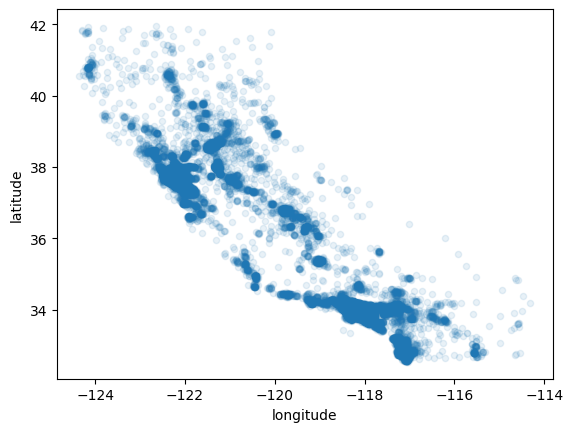

In [25]:
df = strat_train_set.copy()

df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

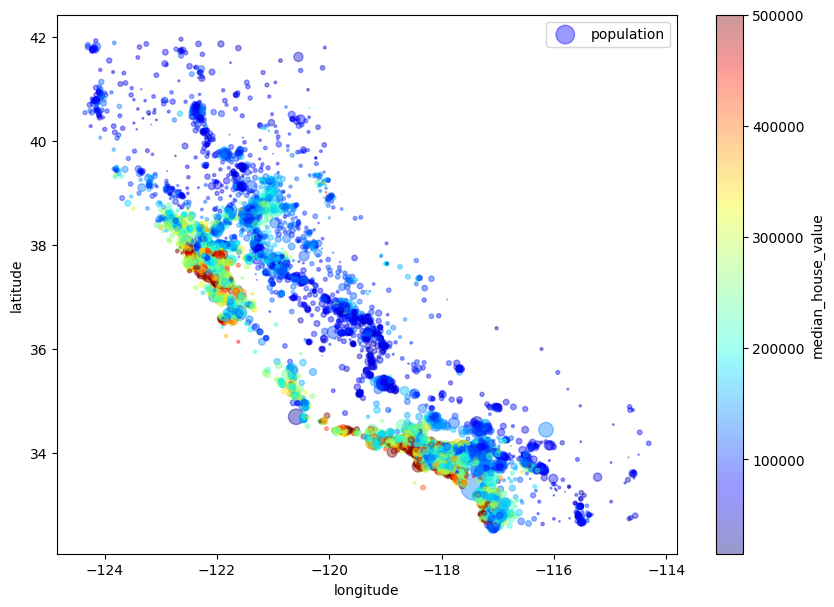

In [ ]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    #size of points depends on population
    s=df["population"]/100, label="population", figsize=(10,7),
    # colort of the circle depends on median house value
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [ ]:
# The correlation coefficient ranges from –1 to 1. When it is close to 1, it means that
# there is a strong positive correlation; for example, the median house value tends to go
# up when the median income goes up. When the coefficient is close to –1, it means
# that there is a strong negative correlation; you can see a small negative correlation
# between the latitude and the median house value (i.e., prices have a slight tendency to
# go down when you go north). Finally, coefficients close to zero mean that there is no
# linear correlation. 
corr_matrix = df.select_dtypes(include="number").corr()["median_house_value"].sort_values(ascending=False)
corr_matrix

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

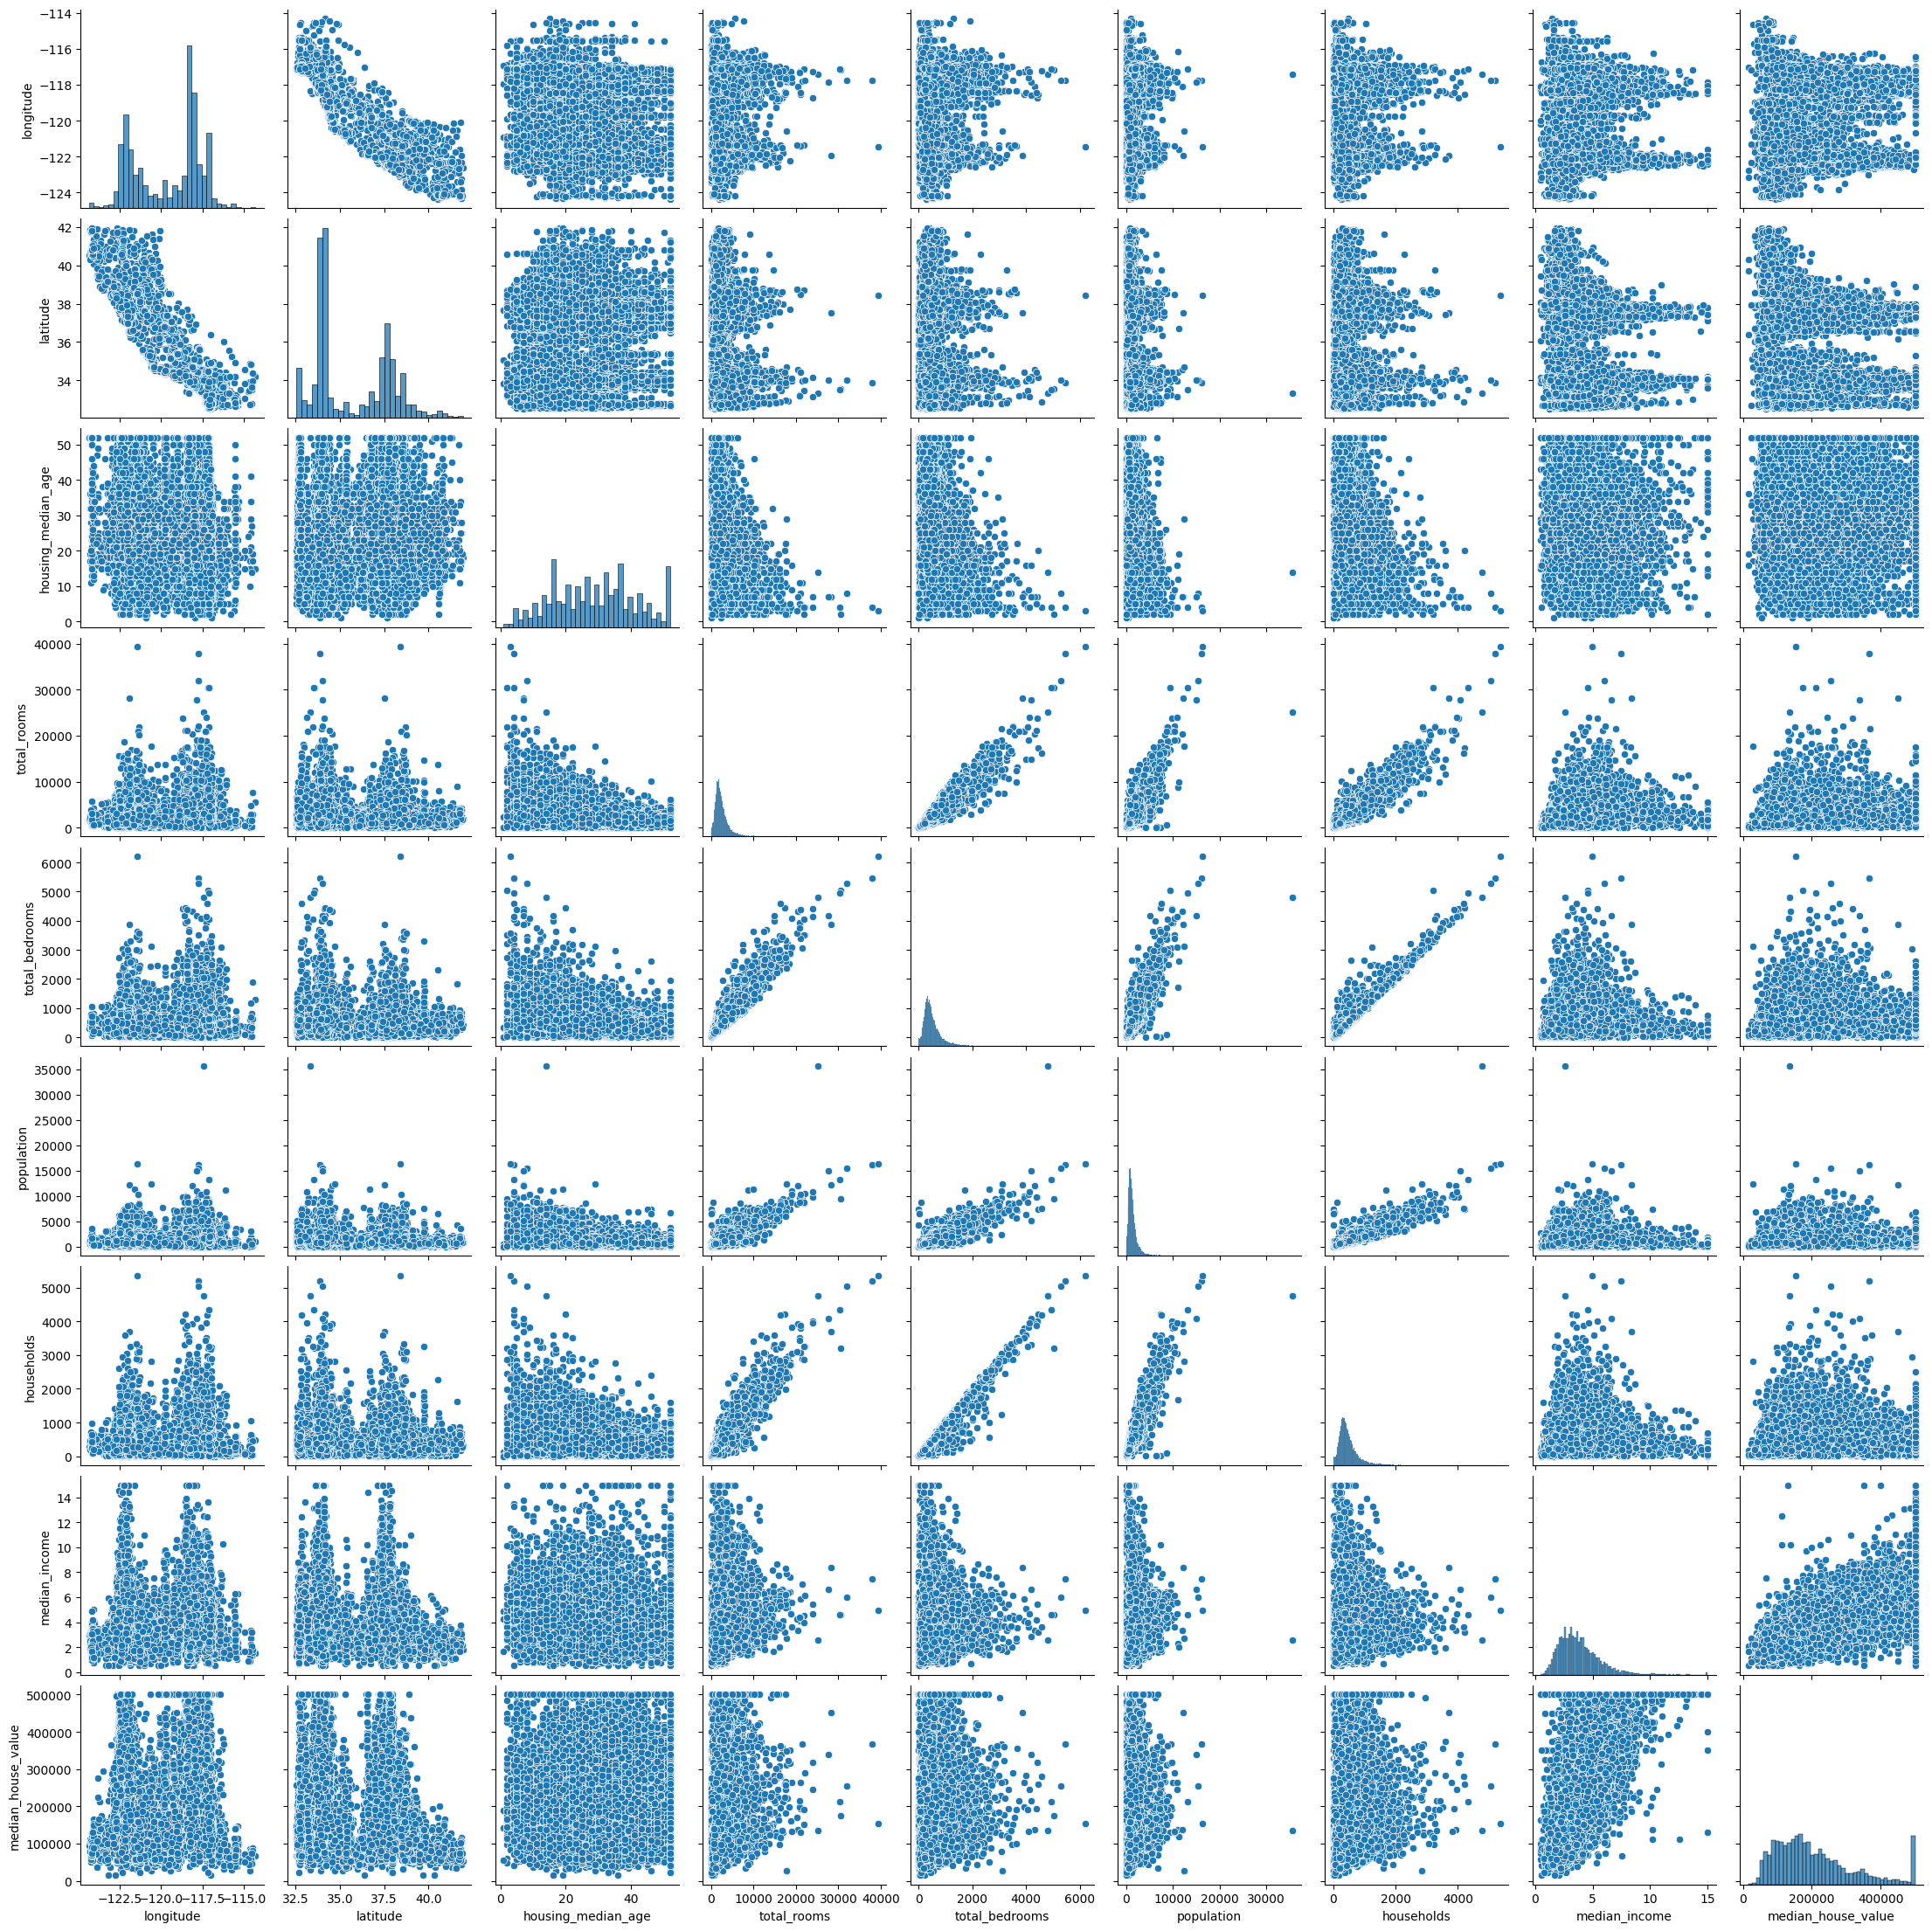

In [ ]:
import seaborn as sns
sns.pairplot(df)

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

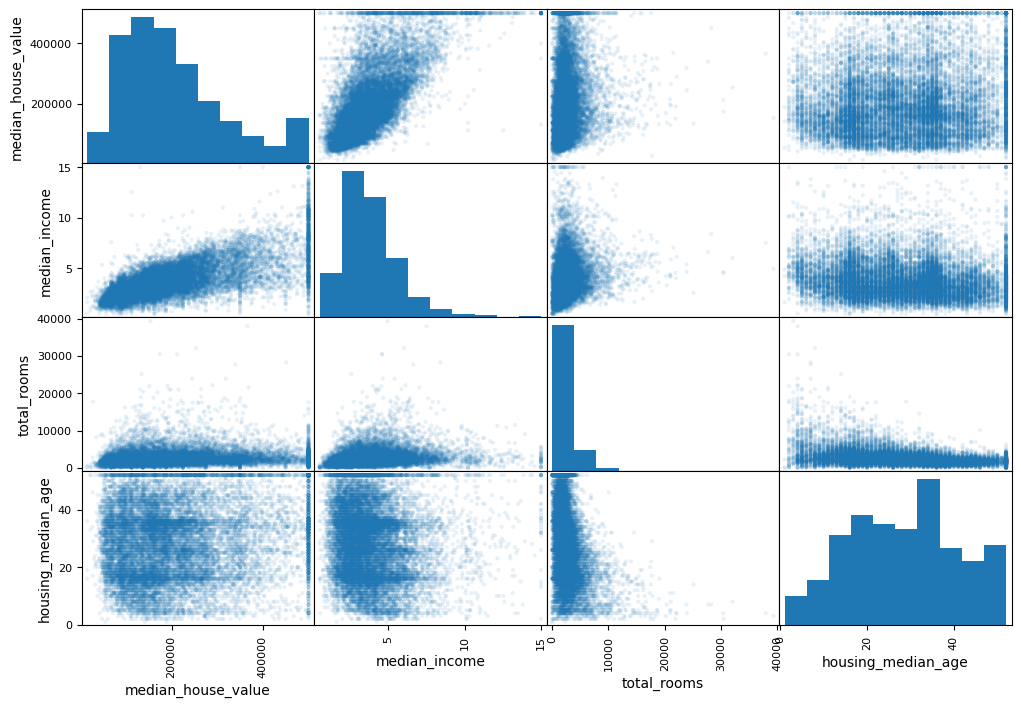

In [39]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8), alpha=0.1)